# View Generated Images

Loads the persisted Phase 4 output (`data/images/{record_id}.npz`) directly — this checks what the batch pipeline actually saved to disk, not a fresh on-the-fly render (that's what `02_signal_to_image.ipynb` does).

Each `data/images/{record_id}.npz` holds `waveform`, `stft`, `cwt` (all `uint8`, shape `(n_windows, 224, 224)`), plus `y` (0=N, 1=A) and `minute_index`, aligned by position.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

root = Path.cwd()
while not (root / "config.yaml").exists():
    root = root.parent
sys.path.insert(0, str(root))

IMAGES_DIR = root / "data" / "images"
REPRESENTATIONS = ["waveform", "stft", "cwt"]

available_records = sorted(p.stem for p in IMAGES_DIR.glob("*.npz"))
print(f"{len(available_records)} records with generated images")
available_records[:10]

70 records with generated images


['a01', 'a02', 'a03', 'a04', 'a05', 'a06', 'a07', 'a08', 'a09', 'a10']

## View one window (all 3 representations)

Change `RECORD_ID` and `WINDOW_INDEX` (a position into that record's arrays, not a minute number) and re-run.

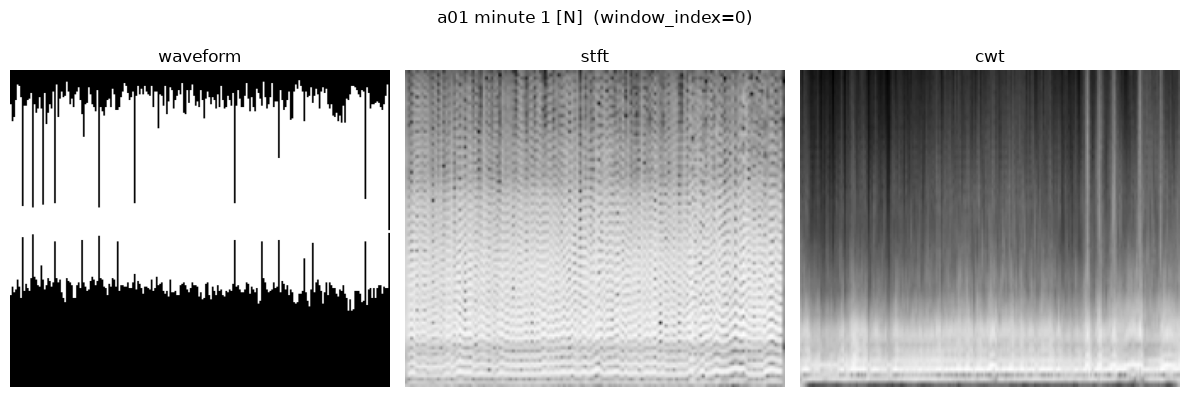

In [2]:
def show_window(record_id: str, window_index: int):
    d = np.load(IMAGES_DIR / f"{record_id}.npz")
    label = "A" if d["y"][window_index] == 1 else "N"
    minute = int(d["minute_index"][window_index])

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, rep in zip(axes, REPRESENTATIONS):
        ax.imshow(d[rep][window_index], cmap="gray", aspect="auto")
        ax.set_title(rep)
        ax.axis("off")
    fig.suptitle(f"{record_id} minute {minute} [{label}]  (window_index={window_index})")
    plt.tight_layout()
    plt.show()


RECORD_ID = "a01"
WINDOW_INDEX = 0
show_window(RECORD_ID, WINDOW_INDEX)

## Browse windows by label

Find the first `n` windows of a given label in a record without knowing indices ahead of time.

In [3]:
def find_indices(record_id: str, label: str, n: int = 5) -> list[int]:
    d = np.load(IMAGES_DIR / f"{record_id}.npz")
    target = 1 if label == "A" else 0
    return np.where(d["y"] == target)[0][:n].tolist()


find_indices("a01", "A", n=5)

[12, 13, 14, 15, 16]

## Grid: several A vs N examples side by side

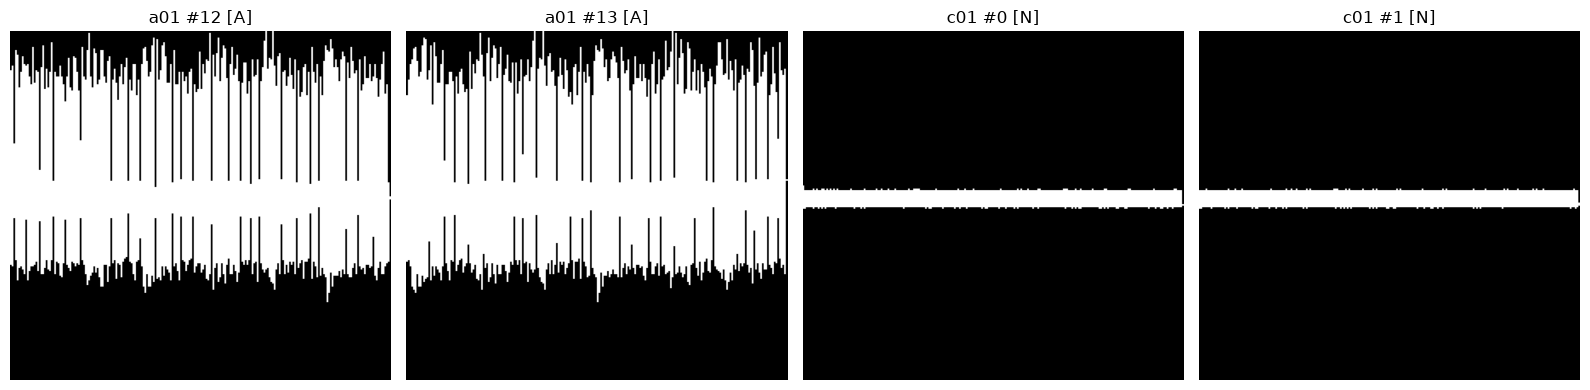

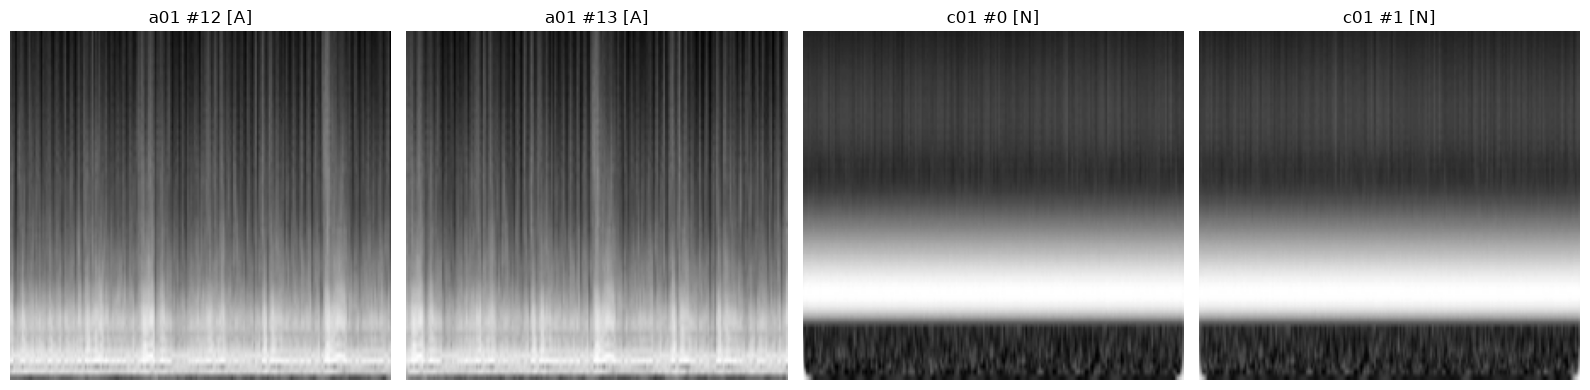

In [4]:
def show_grid(examples: list[tuple[str, int]], rep: str = "waveform"):
    """examples: list of (record_id, window_index) pairs."""
    fig, axes = plt.subplots(1, len(examples), figsize=(4 * len(examples), 4))
    if len(examples) == 1:
        axes = [axes]
    for ax, (record_id, idx) in zip(axes, examples):
        d = np.load(IMAGES_DIR / f"{record_id}.npz")
        label = "A" if d["y"][idx] == 1 else "N"
        ax.imshow(d[rep][idx], cmap="gray", aspect="auto")
        ax.set_title(f"{record_id} #{idx} [{label}]")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


examples = [("a01", i) for i in find_indices("a01", "A", n=2)] + [
    ("c01", i) for i in find_indices("c01", "N", n=2)
]
show_grid(examples, rep="waveform")
show_grid(examples, rep="cwt")

## Random sample across the whole dataset

Pulls uniformly at random from every record with generated images — a broader sanity check than hand-picking specific records.

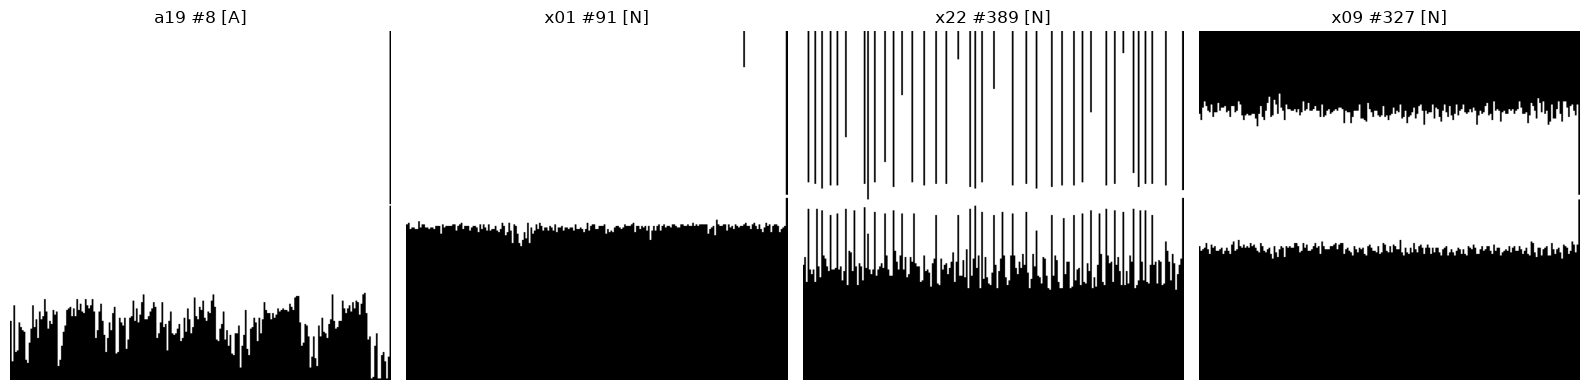

In [5]:
rng = np.random.default_rng(0)
sample_records = rng.choice(available_records, size=4, replace=False)

random_examples = []
for record_id in sample_records:
    d = np.load(IMAGES_DIR / f"{record_id}.npz")
    idx = rng.integers(0, len(d["y"]))
    random_examples.append((record_id, int(idx)))

show_grid(random_examples, rep="waveform")